# Skills vs Sub-Agents: A Deep Dive

AI coding assistants like Claude Code offer two fundamentally different patterns for extending agent capabilities. Understanding the tradeoffs between them is critical for building production agentic systems.

## What They Are

**Skills** are *context injection* patterns — they load structured instructions, examples, or domain knowledge into the current agent's context window before or during execution. The same model instance reads the skill and acts on it.

**Sub-Agents** are *delegation* patterns — they spawn a separate model invocation (a child agent) to handle a bounded task, returning a result to the orchestrator. Execution is distributed across model calls.

## Pattern Breakdown

### Skills (Context Injection)
```
Orchestrator Context Window
┌──────────────────────────────────────────┐
│  System Prompt                           │
│  + SKILL.md injected here  ←────────┐   │
│  + User message                      │   │
│  + Tool results                      │   │
└──────────────────────────────────────┘   │
         │                                 │
         └── reads /skills/X/SKILL.md ─────┘
```
The skill is read into the same context and shapes how the model reasons and acts. There's no new model invocation — just enriched context.

### Sub-Agents (Context Isolation)
```
Orchestrator (Parent)
┌──────────────────────┐
│  task decomposition  │──── spawns ────►  Child Agent Call 1
│  result aggregation  │──── spawns ────►  Child Agent Call 2
│  final synthesis     │◄─── results ───   Child Agent Call N
└──────────────────────┘
```
The orchestrator delegates a subtask, waits for (or fans out to) child completions, and integrates their outputs.

---

**The core mental model:** Skills extend a model's knowledge *within* a call. Sub-agents extend a model's reach *across* calls. The tradeoff is always latency + complexity vs. context cleanliness + scalability.

This notebook demonstrates these tradeoffs with live API calls, real token counts, and visualizations.

## The Experiment

To move beyond theory, we'll run identical tasks through both patterns using live Claude API calls and measure what actually happens.

**What we're building:** A minimal agentic loop — a model that can call file-system tools (`list_directory`, `read_file`, `grep_codebase`) in a multi-turn conversation until it completes a task. This is the same core loop that powers tools like Claude Code, just stripped to its essentials.

**What we're measuring on every turn:**
- **Input tokens** — how much context the model receives (system prompt + conversation history + tool results)
- **Output tokens** — how much the model generates (reasoning + tool calls + final answer)
- **Cumulative context growth** — how the input token count grows turn-over-turn as conversation history accumulates
- **Number of turns and tool calls** — a proxy for task complexity
- **Wall-clock time** — end-to-end latency

**What we want to show:**
1. **Experiment 1 (Simple Lookup):** For a single focused task, skills are cheaper in total tokens — but everything stays in the parent context. Sub-agents cost more overall but leave the parent clean.
2. **Experiment 2 (Composed Workflow):** For multi-step tasks, context pollution becomes the dominant cost. The skill pattern's context balloons with every file read and tool result, while the sub-agent compresses all of that into a summary.
3. **Accumulation Over Time:** After multiple tasks in a session, the skill pattern's parent context grows linearly while the sub-agent pattern stays nearly flat — this is where the real production cost lives.

The target codebase is a small Python project (`src/`) bundled with this notebook — a benchmarking framework with ~18 files across `harness/`, `tools/cli/`, `tools/direct/`, and `tools/mcp/`.

In [8]:
# Setup — imports, API client, tools, and helper functions

import os
import time
import asyncio
import json

import anthropic
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, HTML
from dotenv import load_dotenv

load_dotenv()

matplotlib.rcParams["figure.figsize"] = (10, 5)
matplotlib.rcParams["font.size"] = 11

client = anthropic.AsyncAnthropic()
MODEL = "claude-sonnet-4-20250514"

# --- File tools (the same tools both patterns use) ---

TOOLS = [
    {
        "name": "list_directory",
        "description": "List files and directories at the given path.",
        "input_schema": {
            "type": "object",
            "properties": {"path": {"type": "string", "description": "Directory path"}},
            "required": ["path"],
        },
    },
    {
        "name": "read_file",
        "description": "Read the contents of a file.",
        "input_schema": {
            "type": "object",
            "properties": {"path": {"type": "string", "description": "File path"}},
            "required": ["path"],
        },
    },
    {
        "name": "grep_codebase",
        "description": "Search for a pattern in files under a directory.",
        "input_schema": {
            "type": "object",
            "properties": {
                "directory": {"type": "string", "description": "Directory to search"},
                "pattern": {"type": "string", "description": "Text pattern to search for"},
            },
            "required": ["directory", "pattern"],
        },
    },
]


async def execute_tool(name: str, params: dict) -> str:
    """Execute a tool call."""
    if name == "list_directory":
        try:
            return "\n".join(sorted(os.listdir(params["path"])))
        except Exception as e:
            return f"Error: {e}"
    elif name == "read_file":
        try:
            with open(params["path"]) as f:
                return f.read()
        except Exception as e:
            return f"Error: {e}"
    elif name == "grep_codebase":
        proc = await asyncio.create_subprocess_exec(
            "grep", "-rn", params["pattern"], params["directory"],
            stdout=asyncio.subprocess.PIPE, stderr=asyncio.subprocess.PIPE,
        )
        stdout, _ = await proc.communicate()
        result = stdout.decode().strip()
        return result if result else f"No matches for '{params['pattern']}'"
    return f"Unknown tool: {name}"


# --- Core agent loop with trace capture ---

async def run_agent_loop(system: str, user_prompt: str, label: str = "") -> dict:
    """Run an agentic loop and return detailed trace + metrics."""
    messages = [{"role": "user", "content": user_prompt}]
    total_input = 0
    total_output = 0
    turns = []
    start = time.perf_counter()

    for turn_num in range(1, 21):  # max 20 turns
        response = await client.messages.create(
            model=MODEL, max_tokens=2048, system=system,
            tools=TOOLS, messages=messages,
        )
        total_input += response.usage.input_tokens
        total_output += response.usage.output_tokens

        turn_info = {
            "turn": turn_num,
            "input_tokens": response.usage.input_tokens,
            "output_tokens": response.usage.output_tokens,
            "cumulative_input": total_input,
            "tool_calls": [],
            "stop_reason": response.stop_reason,
        }

        if response.stop_reason != "tool_use":
            final_text = "".join(b.text for b in response.content if hasattr(b, "text"))
            turn_info["final_text"] = final_text
            turns.append(turn_info)
            break

        tool_results = []
        for block in response.content:
            if block.type == "tool_use":
                result = await execute_tool(block.name, block.input)
                turn_info["tool_calls"].append({
                    "tool": block.name,
                    "input": block.input,
                    "result_preview": result[:150],
                })
                tool_results.append({
                    "type": "tool_result",
                    "tool_use_id": block.id,
                    "content": result,
                })

        turns.append(turn_info)
        messages.append({"role": "assistant", "content": response.content})
        messages.append({"role": "user", "content": tool_results})

    elapsed = time.perf_counter() - start

    return {
        "label": label,
        "total_input_tokens": total_input,
        "total_output_tokens": total_output,
        "total_tokens": total_input + total_output,
        "elapsed_s": round(elapsed, 1),
        "num_turns": len(turns),
        "num_tool_calls": sum(len(t["tool_calls"]) for t in turns),
        "turns": turns,
        "final_text": turns[-1].get("final_text", ""),
    }


# --- Display helpers ---

TOOL_ICONS = {"list_directory": "\U0001F4C2", "read_file": "\U0001F4C4", "grep_codebase": "\U0001F50D"}

def _short_path(path: str) -> str:
    """Shorten a file path for display."""
    parts = path.split("/")
    if len(parts) > 3:
        return ".../" + "/".join(parts[-2:])
    return path

def _tool_desc(tc: dict) -> str:
    """One-line description of a tool call."""
    icon = TOOL_ICONS.get(tc["tool"], "\U0001F527")
    inp = tc["input"]
    if tc["tool"] == "list_directory":
        return f'{icon} <code>list_directory</code>({_short_path(inp["path"])})'
    elif tc["tool"] == "read_file":
        return f'{icon} <code>read_file</code>({_short_path(inp["path"])})'
    elif tc["tool"] == "grep_codebase":
        return f'{icon} <code>grep</code>("{inp["pattern"]}")'
    return f'{icon} <code>{tc["tool"]}</code>'

def print_trace(result: dict):
    """Display a rich HTML table with context growth progress bars."""
    max_ctx = result["total_input_tokens"]
    turns = result["turns"]

    # Header
    rows = []
    rows.append(f"""
    <div style="background:#1e1e2e; color:#cdd6f4; padding:12px 16px; border-radius:8px 8px 0 0; font-family:monospace;">
        <strong>{result['label']}</strong><br>
        <span style="color:#a6adc8;">{result['num_turns']} turns &bull; {result['num_tool_calls']} tool calls &bull; {result['elapsed_s']}s &bull;
        {result['total_tokens']:,} total tokens</span>
    </div>
    """)

    # Table
    rows.append("""
    <table style="width:100%; border-collapse:collapse; font-family:monospace; font-size:13px; margin:0;">
    <tr style="background:#313244; color:#cdd6f4;">
        <th style="padding:8px; text-align:center; width:50px;">Turn</th>
        <th style="padding:8px; text-align:left;">Action</th>
        <th style="padding:8px; text-align:right; width:90px;">Input</th>
        <th style="padding:8px; text-align:right; width:90px;">Output</th>
        <th style="padding:8px; text-align:left; width:280px;">Context Growth</th>
    </tr>
    """)

    for turn in turns:
        cum = turn["cumulative_input"]
        pct = cum / max_ctx * 100 if max_ctx > 0 else 0

        # Determine bar color based on fill level
        if pct < 33:
            bar_color = "#a6e3a1"  # green
        elif pct < 66:
            bar_color = "#f9e2af"  # yellow
        else:
            bar_color = "#fab387"  # orange

        # Action description
        if turn["tool_calls"]:
            actions = "<br>".join(_tool_desc(tc) for tc in turn["tool_calls"])
        elif "final_text" in turn:
            preview = turn["final_text"][:120].replace("<", "&lt;").replace("\n", " ")
            actions = f'\U00002705 <em>{preview}...</em>'
        else:
            actions = "<em>thinking...</em>"

        # Progress bar
        bar = f"""
        <div style="display:flex; align-items:center; gap:8px;">
            <div style="flex:1; background:#45475a; border-radius:4px; height:16px; overflow:hidden;">
                <div style="width:{pct:.0f}%; background:{bar_color}; height:100%; border-radius:4px;
                            transition:width 0.3s;"></div>
            </div>
            <span style="white-space:nowrap; color:#bac2de; min-width:80px; text-align:right;">{cum:,}</span>
        </div>
        """

        bg = "#1e1e2e" if turn["turn"] % 2 == 1 else "#181825"
        rows.append(f"""
        <tr style="background:{bg}; color:#cdd6f4;">
            <td style="padding:8px; text-align:center; color:#89b4fa; font-weight:bold;">{turn['turn']}</td>
            <td style="padding:8px;">{actions}</td>
            <td style="padding:8px; text-align:right;">{turn['input_tokens']:,}</td>
            <td style="padding:8px; text-align:right;">{turn['output_tokens']:,}</td>
            <td style="padding:8px;">{bar}</td>
        </tr>
        """)

    rows.append("</table>")

    # Footer summary
    rows.append(f"""
    <div style="background:#313244; color:#a6adc8; padding:8px 16px; border-radius:0 0 8px 8px;
                font-family:monospace; font-size:12px;">
        Total: {result['total_input_tokens']:,} input + {result['total_output_tokens']:,} output
        = <strong style="color:#cdd6f4;">{result['total_tokens']:,}</strong> tokens
    </div>
    """)

    display(HTML("".join(rows)))


# Target codebase (bundled src/ directory from the MCP benchmark project)
TARGET_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "src")
print(f"Target codebase: {TARGET_DIR}")
print(f"Model: {MODEL}")
print(f"API key: {'set' if os.environ.get('ANTHROPIC_API_KEY') else 'MISSING'}")

Target codebase: /Users/odedha/datarails/projects/personal/skills-vs-subagents-notebook/src
Model: claude-sonnet-4-20250514
API key: set


## Experiment 1: Token Usage

| Dimension | Skills | Sub-Agents |
|---|---|---|
| **Input tokens** | Higher per-call (skill content loaded into context) | Split across calls; each child gets only its slice |
| **Output tokens** | Single generation | Summed across all children |
| **Redundant tokens** | Skill injected on every call even if only partially relevant | Each child gets a clean, minimal context |
| **Context efficiency** | Poor if skill is large and task is narrow | Better — child receives only what it needs |

**Key insight:** A 2,000-token skill injected on every request adds 2,000 input tokens *per call*. At scale this compounds fast. Sub-agents pay per-spawn latency instead.

Let's measure this with a simple task: **find a specific function in a codebase and return its signature.**

### Pattern 1: Skill (Context Injection)

Every tool call, every file content, every response — it all stays in the conversation context.

In [9]:
# Experiment 1a: Simple task — Skill pattern

SIMPLE_TASK = f"Find the function `run_benchmark` in the codebase at {TARGET_DIR}. Return its full signature and which file it's defined in."

SKILL_SYSTEM = "You are a code search assistant. Find the requested function definition. Be precise and concise — return only the signature and file path."

skill_simple = await run_agent_loop(
    system=f"{SKILL_SYSTEM}\n\nYou have access to file tools. Complete the task thoroughly.",
    user_prompt=SIMPLE_TASK,
    label="Skill Pattern — Simple Lookup",
)

print_trace(skill_simple)

Turn,Action,Input,Output,Context Growth
1,"🔍 grep(""def run_benchmark"")",628,120,628
2,📄 read_file(.../harness/runner.py),801,99,"1,429"
3,"✅ **Function signature:** ```python async def run_benchmark( provider, prompt: str, model: str, llm: str =...","3,574",103,"5,003"


### Pattern 2: Sub-Agent (Context Isolation)

Now the same task, but using delegation. A **child agent** does the actual work in its own conversation, then returns a summary to the **parent agent**. The parent never sees the tool calls or file contents — only the child's final answer.

This also lets us observe **latency**: skills complete in a single inference pass, while sub-agents add network + inference overhead per spawn.

In [10]:
# Experiment 1b: Simple task — Sub-Agent pattern

# Step 1: Child agent does the work
AGENT_SYSTEM = "You are a code search agent. Find the requested function definition. Be precise and concise — your response will be passed to another agent as a summary."

child_simple = await run_agent_loop(
    system=f"{AGENT_SYSTEM}\n\nYou have access to file tools. Complete the task thoroughly.",
    user_prompt=SIMPLE_TASK,
    label="Sub-Agent (Child) — Simple Lookup",
)

print_trace(child_simple)
print(f"\n{'─' * 60}")
print(f"  Child's summary (this is ALL the parent will see):")
print(f"{'─' * 60}")
print(f"  {child_simple['final_text'][:300]}")

# Step 2: Parent receives only the summary
print(f"\n{'─' * 60}")
print(f"  Now the parent agent processes the summary...")
print(f"{'─' * 60}")

parent_response = await client.messages.create(
    model=MODEL,
    max_tokens=1024,
    system="You are a senior developer. You delegated a task to a sub-agent. Review its summary and provide your final response.",
    messages=[{
        "role": "user",
        "content": f"I asked a sub-agent to: {SIMPLE_TASK}\n\nThe sub-agent returned:\n\n{child_simple['final_text']}\n\nProvide your final response.",
    }],
)

parent_input = parent_response.usage.input_tokens
parent_output = parent_response.usage.output_tokens
parent_text = "".join(b.text for b in parent_response.content if hasattr(b, "text"))

print(f"\n  Parent: {parent_input:,} input + {parent_output:,} output = {parent_input + parent_output:,} tokens")
print(f"  Response: {parent_text[:200]}")

# Package sub-agent results for comparison
subagent_simple = {
    "label": "Sub-Agent Pattern — Simple Lookup",
    "parent_input": parent_input,
    "parent_output": parent_output,
    "parent_tokens": parent_input + parent_output,
    "child_input": child_simple["total_input_tokens"],
    "child_output": child_simple["total_output_tokens"],
    "child_tokens": child_simple["total_tokens"],
    "total_tokens": (parent_input + parent_output) + child_simple["total_tokens"],
    "elapsed_s": child_simple["elapsed_s"],  # child dominates time
}

Turn,Action,Input,Output,Context Growth
1,"🔍 grep(""def run_benchmark"")",632,126,632
2,📄 read_file(.../harness/runner.py),811,102,"1,443"
3,✅ Perfect! I found the `run_benchmark` function. Here are the details: **File:** `/Users/odedha/datarails/projects/person...,"3,587",189,"5,030"



────────────────────────────────────────────────────────────
  Child's summary (this is ALL the parent will see):
────────────────────────────────────────────────────────────
  Perfect! I found the `run_benchmark` function. Here are the details:

**File:** `/Users/odedha/datarails/projects/personal/skills-vs-subagents-notebook/src/harness/runner.py`

**Full Function Signature:**
```python
async def run_benchmark(
    provider,
    prompt: str,
    model: str,
    llm: str 

────────────────────────────────────────────────────────────
  Now the parent agent processes the summary...
────────────────────────────────────────────────────────────

  Parent: 295 input + 237 output = 532 tokens
  Response: The sub-agent has successfully located and provided the complete information about the `run_benchmark` function. Here's my final response:

## Function Details

**File Location:** `/Users/odedha/datar


### Experiment 1: Results — Token Usage & Latency

Let's compare side by side:
1. **Total tokens** — the raw cost of each pattern
2. **Parent context tokens** — how much each pattern leaves in the parent conversation

| Pattern | Latency Profile |
|---|---|
| **Skills** | Single inference pass — latency is one model round-trip |
| **Sub-agents (sequential)** | Multiplied — N subtasks = N round-trips chained |
| **Sub-agents (parallel/fan-out)** | Better — N round-trips in parallel, bottleneck is the slowest child |

Skills win on latency almost always for single-turn tasks. Sub-agents introduce network + inference overhead per spawn, but parallel fan-out can outperform a single bloated context when tasks are truly independent.

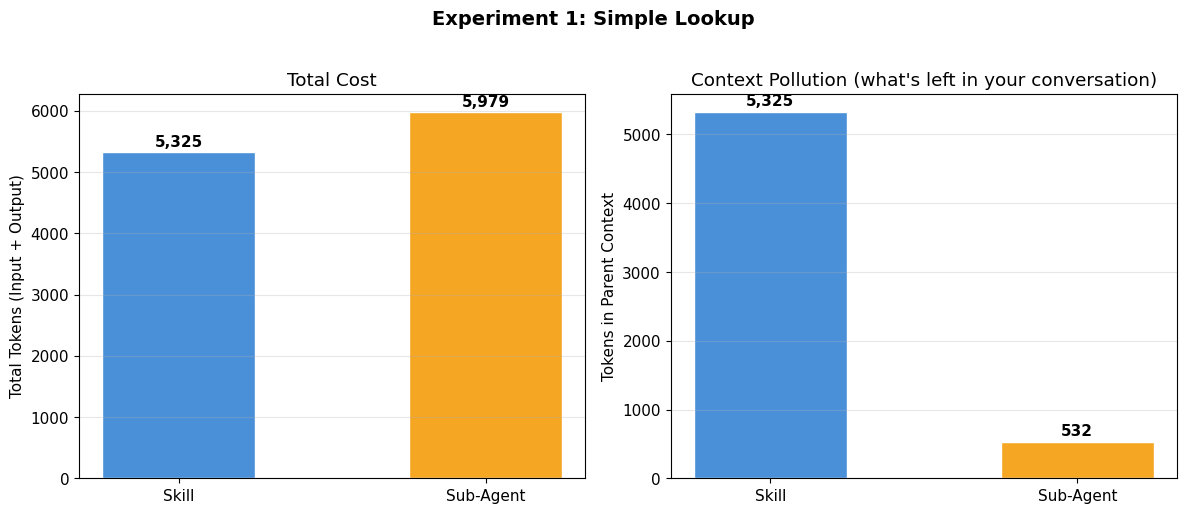


Skill: 5,325 total tokens, all in parent context
Sub-Agent: 5,979 total tokens, but only 532 in parent context

For a simple task, the skill is cheaper. But the sub-agent keeps the parent clean.


In [11]:
# Experiment 1: Side-by-side comparison chart

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1: Total tokens
labels = ["Skill", "Sub-Agent"]
skill_total = skill_simple["total_tokens"]
sub_total = subagent_simple["total_tokens"]

bars = ax1.bar(labels, [skill_total, sub_total], color=["#4A90D9", "#F5A623"], edgecolor="white", width=0.5)
ax1.set_ylabel("Total Tokens (Input + Output)")
ax1.set_title("Total Cost")
for bar, val in zip(bars, [skill_total, sub_total]):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
             f"{val:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax1.grid(axis="y", alpha=0.3)

# Chart 2: Parent context tokens (what's left after the task)
skill_parent = skill_simple["total_tokens"]  # everything is in parent
sub_parent = subagent_simple["parent_tokens"]  # only the summary exchange

bars2 = ax2.bar(labels, [skill_parent, sub_parent], color=["#4A90D9", "#F5A623"], edgecolor="white", width=0.5)
ax2.set_ylabel("Tokens in Parent Context")
ax2.set_title("Context Pollution (what's left in your conversation)")
for bar, val in zip(bars2, [skill_parent, sub_parent]):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
             f"{val:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax2.grid(axis="y", alpha=0.3)

plt.suptitle("Experiment 1: Simple Lookup", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"\nSkill: {skill_total:,} total tokens, all in parent context")
print(f"Sub-Agent: {sub_total:,} total tokens, but only {sub_parent:,} in parent context")
print(f"\nFor a simple task, the skill is cheaper. But the sub-agent keeps the parent clean.")

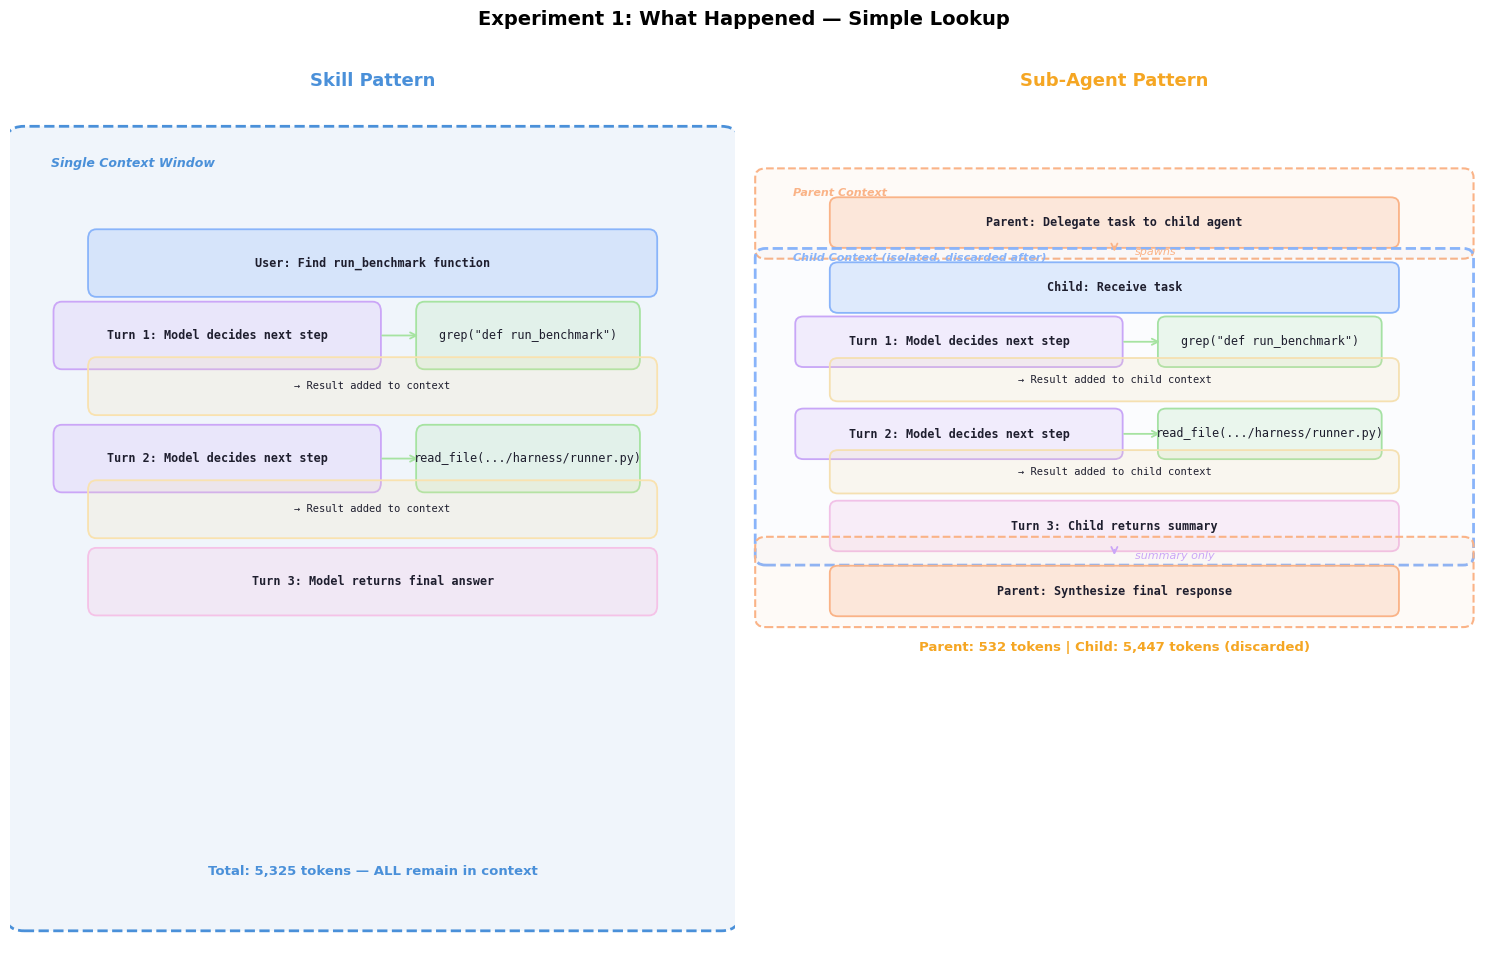

In [12]:
# Experiment 1: Flow Diagrams — What Actually Happened

from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def _tool_label(tc):
    """Short label for a tool call."""
    if tc["tool"] == "list_directory":
        return f"list_directory({_short_path(tc['input']['path'])})"
    elif tc["tool"] == "read_file":
        return f"read_file({_short_path(tc['input']['path'])})"
    elif tc["tool"] == "grep_codebase":
        return f'grep("{tc["input"]["pattern"]}")'
    return tc["tool"]

def _draw_box(ax, x, y, w, h, label, facecolor, edgecolor, fontsize=8.5, bold=False):
    """Draw a rounded box with centered label."""
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
        boxstyle="round,pad=0.12", facecolor=facecolor, edgecolor=edgecolor, linewidth=1.3)
    ax.add_patch(box)
    weight = "bold" if bold else "normal"
    ax.text(x, y, label, ha="center", va="center", fontsize=fontsize,
            fontfamily="monospace", color="#1e1e2e", fontweight=weight)
    return y

def _draw_arrow(ax, x1, y1, x2, y2, color="#888888", style="->"):
    """Draw an arrow between two points."""
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
               arrowprops=dict(arrowstyle=style, color=color, lw=1.3,
                              connectionstyle="arc3,rad=0"))

def _draw_curved_arrow(ax, x1, y1, x2, y2, color="#888888", label="", rad=0.3):
    """Draw a curved arrow with optional label."""
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
               arrowprops=dict(arrowstyle="->", color=color, lw=1.2,
                              connectionstyle=f"arc3,rad={rad}"))
    if label:
        mx, my = (x1 + x2) / 2 + rad * 1.5, (y1 + y2) / 2
        ax.text(mx, my, label, fontsize=7, color=color, ha="center", va="center", style="italic")


def draw_flow(skill_result, subagent_child_result, subagent_parent_tokens, title="Experiment Flow"):
    """Draw side-by-side flow diagrams showing model→tool→result cycles."""

    # --- Collect turn-by-turn flow for each ---
    def build_flow(result):
        """Returns list of (turn_num, 'model'|'tool'|'response', label, result_preview)."""
        flow = []
        for turn in result["turns"]:
            if turn["tool_calls"]:
                for tc in turn["tool_calls"]:
                    flow.append(("tool_call", _tool_label(tc), tc.get("result_preview", "")[:60]))
            if "final_text" in turn:
                flow.append(("response", "Final Answer", turn["final_text"][:80].replace("\n", " ")))
        return flow

    skill_flow = build_flow(skill_result)
    child_flow = build_flow(subagent_child_result)

    # Calculate layout heights
    # Each tool call = model decision + tool exec + result back = 3 rows
    # Final response = 1 row
    def count_rows(flow):
        return sum(3 if f[0] == "tool_call" else 1 for f in flow)

    skill_rows = count_rows(skill_flow) + 1  # +1 for user prompt
    child_rows = count_rows(child_flow) + 1
    sub_rows = child_rows + 4  # parent delegate + summary + parent synthesize + spacing

    max_rows = max(skill_rows, sub_rows)
    fig_h = max(6, max_rows * 0.55 + 3)
    fig, (ax_skill, ax_sub) = plt.subplots(1, 2, figsize=(15, fig_h))

    row_h = 0.9  # vertical spacing between rows
    model_x = 3.0  # model column x
    tool_x = 7.5   # tool column x
    box_w = 4.5
    box_h = 0.6

    # ===================== SKILL PATTERN (left) =====================
    ax = ax_skill
    ax.set_xlim(0, 10.5)
    ax.set_ylim(-skill_rows * row_h - 1.5, 2.0)
    ax.axis("off")
    ax.set_aspect("auto")
    ax.set_title("Skill Pattern", fontsize=13, fontweight="bold", color="#4A90D9", pad=12)

    # Context boundary
    ctx_rect = FancyBboxPatch((0.2, -skill_rows * row_h - 0.8), 10.1, skill_rows * row_h + 2.2,
        boxstyle="round,pad=0.3", facecolor="#4A90D915", edgecolor="#4A90D9",
        linewidth=2, linestyle="--")
    ax.add_patch(ctx_rect)
    ax.text(0.6, 1.2, "Single Context Window", fontsize=9, color="#4A90D9",
            fontweight="bold", style="italic")

    # User prompt
    cy = 0
    _draw_box(ax, 5.25, cy, 8, box_h, "User: Find run_benchmark function", "#89b4fa40", "#89b4fa", bold=True)
    cy -= row_h

    # Draw each step
    turn_num = 1
    for i, (ftype, label, preview) in enumerate(skill_flow):
        if ftype == "tool_call":
            # Model decides
            _draw_box(ax, model_x, cy, box_w, box_h,
                     f"Turn {turn_num}: Model decides next step", "#cba6f730", "#cba6f7", bold=True)
            _draw_arrow(ax, model_x + box_w/2 + 0.1, cy, tool_x - box_w/2 + 0.7, cy, color="#a6e3a1")
            # Tool executes
            display_label = label if len(label) < 40 else label[:37] + "..."
            _draw_box(ax, tool_x, cy, box_w - 1.5, box_h, display_label, "#a6e3a130", "#a6e3a1")
            cy -= row_h * 0.7
            # Result flows back
            result_short = preview[:40] + "..." if len(preview) > 40 else preview
            _draw_box(ax, 5.25, cy, 8, box_h * 0.8,
                     f"→ Result added to context", "#f9e2af30", "#f9e2af", fontsize=7.5)
            cy -= row_h
            turn_num += 1
        elif ftype == "response":
            _draw_box(ax, 5.25, cy, 8, box_h,
                     f"Turn {turn_num}: Model returns final answer", "#f5c2e740", "#f5c2e7", bold=True)

    # Token summary
    ax.text(5.25, -skill_rows * row_h - 0.4,
            f"Total: {skill_result['total_tokens']:,} tokens — ALL remain in context",
            ha="center", fontsize=9.5, color="#4A90D9", fontweight="bold")

    # ===================== SUB-AGENT PATTERN (right) =====================
    ax = ax_sub
    ax.set_xlim(0, 10.5)
    ax.set_ylim(-sub_rows * row_h - 1.5, 2.0)
    ax.axis("off")
    ax.set_aspect("auto")
    ax.set_title("Sub-Agent Pattern", fontsize=13, fontweight="bold", color="#F5A623", pad=12)

    cy = 0

    # Parent: delegate
    parent_top_y = cy + box_h/2 + 0.3
    _draw_box(ax, 5.25, cy, 8, box_h, "Parent: Delegate task to child agent", "#fab38740", "#fab387", bold=True)

    # Parent context boundary (top)
    p_rect = FancyBboxPatch((0.2, cy - box_h/2 - 0.15), 10.1, box_h + 0.6,
        boxstyle="round,pad=0.15", facecolor="#fab38710", edgecolor="#fab387",
        linewidth=1.5, linestyle="--")
    ax.add_patch(p_rect)
    ax.text(0.6, cy + box_h/2 + 0.15, "Parent Context", fontsize=8, color="#fab387",
            fontweight="bold", style="italic")

    cy -= row_h * 1.2
    _draw_arrow(ax, 5.25, cy + row_h * 1.2 - box_h/2 - 0.05, 5.25, cy + box_h/2 + 0.25, color="#fab387")
    ax.text(5.25 + 0.3, cy + row_h * 0.6, "spawns", fontsize=8, color="#fab387", style="italic")

    # Child context boundary
    child_top_y = cy + box_h/2 + 0.2

    # Child: user prompt
    _draw_box(ax, 5.25, cy, 8, box_h, "Child: Receive task", "#89b4fa40", "#89b4fa", bold=True)
    cy -= row_h

    # Child turns
    turn_num = 1
    for i, (ftype, label, preview) in enumerate(child_flow):
        if ftype == "tool_call":
            _draw_box(ax, model_x, cy, box_w, box_h,
                     f"Turn {turn_num}: Model decides next step", "#cba6f730", "#cba6f7", bold=True)
            _draw_arrow(ax, model_x + box_w/2 + 0.1, cy, tool_x - box_w/2 + 0.7, cy, color="#a6e3a1")
            display_label = label if len(label) < 40 else label[:37] + "..."
            _draw_box(ax, tool_x, cy, box_w - 1.5, box_h, display_label, "#a6e3a130", "#a6e3a1")
            cy -= row_h * 0.7
            _draw_box(ax, 5.25, cy, 8, box_h * 0.8,
                     f"→ Result added to child context", "#f9e2af30", "#f9e2af", fontsize=7.5)
            cy -= row_h
            turn_num += 1
        elif ftype == "response":
            _draw_box(ax, 5.25, cy, 8, box_h,
                     f"Turn {turn_num}: Child returns summary", "#f5c2e740", "#f5c2e7", bold=True)

    child_bottom_y = cy - box_h/2 - 0.2

    # Child context boundary box
    c_rect = FancyBboxPatch((0.2, child_bottom_y), 10.1, child_top_y - child_bottom_y,
        boxstyle="round,pad=0.15", facecolor="#89b4fa08", edgecolor="#89b4fa",
        linewidth=2, linestyle="--")
    ax.add_patch(c_rect)
    ax.text(0.6, child_top_y - 0.05, "Child Context (isolated, discarded after)",
            fontsize=8, color="#89b4fa", fontweight="bold", style="italic")

    cy -= row_h * 1.2

    # Summary arrow
    _draw_arrow(ax, 5.25, cy + row_h * 1.2 - box_h/2 - 0.05, 5.25, cy + box_h/2 + 0.25, color="#cba6f7")
    ax.text(5.25 + 0.3, cy + row_h * 0.6, "summary only", fontsize=8, color="#cba6f7", style="italic")

    # Parent: synthesize
    _draw_box(ax, 5.25, cy, 8, box_h, "Parent: Synthesize final response", "#fab38740", "#fab387", bold=True)

    # Parent context boundary (bottom)
    p_rect2 = FancyBboxPatch((0.2, cy - box_h/2 - 0.15), 10.1, box_h + 0.6,
        boxstyle="round,pad=0.15", facecolor="#fab38710", edgecolor="#fab387",
        linewidth=1.5, linestyle="--")
    ax.add_patch(p_rect2)

    # Token summary
    ax.text(5.25, cy - box_h/2 - 0.7,
            f"Parent: {subagent_parent_tokens:,} tokens | Child: {subagent_child_result['total_tokens']:,} tokens (discarded)",
            ha="center", fontsize=9.5, color="#F5A623", fontweight="bold")

    plt.suptitle(title, fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


draw_flow(skill_simple, child_simple, subagent_simple["parent_tokens"],
          title="Experiment 1: What Happened — Simple Lookup")

## Experiment 2: Context Pollution

This is where the distinction gets subtle and important.

**Skills pollute the current context window:**
- Every token of the skill competes with user input, prior tool results, and working memory
- In long agentic runs, skill content can push relevant state toward the context boundary
- Irrelevant skill sections can subtly bias reasoning (the model "sees" them even when not needed)

**Sub-agents isolate pollution:**
- Each child has its own clean window — no crosstalk from sibling tasks
- The orchestrator only receives the output of child work, not the full reasoning trace
- Risk: the orchestrator's context grows as it aggregates child results — you trade intra-call pollution for inter-call accumulation

**Practical implication:** In a long-running orchestration loop, sub-agents are better at preventing *context rot*. Skills are better for short, focused tasks where you want the model to reason holistically.

Let's scale up the task to see this in action. This task requires **multiple steps that build on each other**: research a codebase, analyze its architecture, then recommend an improvement.

In [13]:
# Experiment 2a: Complex task — Skill pattern

COMPLEX_TASK = f"""For the codebase at {TARGET_DIR}:
Step 1 — Research: Read the project structure and understand what it does.
Step 2 — Analyze: Identify the main architectural pattern (how tools, harness, and benchmark relate).
Step 3 — Recommend: Suggest one concrete improvement to the codebase with rationale.
Return all three steps clearly labeled."""

SKILL_COMPLEX_SYSTEM = "You are a senior code reviewer. Follow the three steps in order: research the codebase, analyze its architecture, then recommend improvements. Use the tools to read files as needed."

skill_complex = await run_agent_loop(
    system=f"{SKILL_COMPLEX_SYSTEM}\n\nYou have access to file tools. Complete the task thoroughly.",
    user_prompt=COMPLEX_TASK,
    label="Skill Pattern — Composed Workflow",
)

print_trace(skill_complex)

Turn,Action,Input,Output,Context Growth
1,📂 list_directory(.../skills-vs-subagents-notebook/src),693,100,693
2,📂 list_directory(.../src/harness),823,98,"1,516"
3,📂 list_directory(.../src/tools),951,80,"2,467"
4,📄 read_file(.../src/__main__.py),"1,058",94,"3,525"
5,📄 read_file(.../src/benchmark.py),"1,194",82,"4,719"
6,📄 read_file(.../harness/runner.py),"2,900",95,"7,619"
7,📄 read_file(.../tools/interface.py),"5,669",93,"13,288"
8,📂 list_directory(.../tools/direct),"5,920",93,"19,208"
9,📄 read_file(.../direct/tools.py),"6,033",86,"25,241"
10,📂 list_directory(.../tools/cli),"6,754",90,"31,995"


In [16]:
# Experiment 2b: Complex task — Sub-Agent pattern

AGENT_COMPLEX_SYSTEM = "You are a senior code reviewer agent. Follow the three steps in order: research, analyze, recommend. Be thorough but concise — your response will be passed to another agent."

child_complex = await run_agent_loop(
    system=f"{AGENT_COMPLEX_SYSTEM}\n\nYou have access to file tools. Complete the task thoroughly.",
    user_prompt=COMPLEX_TASK,
    label="Sub-Agent (Child) — Composed Workflow",
)

print_trace(child_complex)
print(f"\n{'─' * 60}")
print(f"  Child's summary ({len(child_complex['final_text'])} chars):")
print(f"{'─' * 60}")
print(f"  {child_complex['final_text'][:500]}...")

# Parent synthesizes
parent_complex = await client.messages.create(
    model=MODEL,
    max_tokens=1024,
    system="You are a senior developer. You delegated a task to a sub-agent. Review its summary and provide your final response.",
    messages=[{
        "role": "user",
        "content": f"I asked a sub-agent to:\n\n{COMPLEX_TASK}\n\nThe sub-agent returned:\n\n{child_complex['final_text']}\n\nProvide your final response.",
    }],
)

parent_complex_in = parent_complex.usage.input_tokens
parent_complex_out = parent_complex.usage.output_tokens

print(f"\n  Parent: {parent_complex_in:,} input + {parent_complex_out:,} output = {parent_complex_in + parent_complex_out:,} tokens")

subagent_complex = {
    "label": "Sub-Agent Pattern — Composed Workflow",
    "parent_input": parent_complex_in,
    "parent_output": parent_complex_out,
    "parent_tokens": parent_complex_in + parent_complex_out,
    "child_input": child_complex["total_input_tokens"],
    "child_output": child_complex["total_output_tokens"],
    "child_tokens": child_complex["total_tokens"],
    "total_tokens": (parent_complex_in + parent_complex_out) + child_complex["total_tokens"],
    "elapsed_s": child_complex["elapsed_s"],
}

Turn,Action,Input,Output,Context Growth
1,📂 list_directory(.../skills-vs-subagents-notebook/src),693,104,693
2,📂 list_directory(.../src/harness),827,81,"1,520"
3,📂 list_directory(.../src/tools),938,80,"2,458"
4,📂 list_directory(.../tools/cli),"1,045",82,"3,503"
5,📂 list_directory(.../tools/direct),"1,165",82,"4,668"
6,📂 list_directory(.../tools/mcp),"1,267",83,"5,935"
7,📄 read_file(.../src/__main__.py),"1,370",98,"7,305"
8,📄 read_file(.../src/benchmark.py),"1,510",82,"8,815"
9,📄 read_file(.../tools/interface.py),"3,216",84,"12,031"
10,📄 read_file(.../harness/runner.py),"3,458",85,"15,489"



────────────────────────────────────────────────────────────
  Child's summary (3962 chars):
────────────────────────────────────────────────────────────
  Based on my research, analysis, and review, here are the three steps:

## Step 1 — Research: Project Structure and Purpose

This is a benchmark codebase that compares three different approaches to tool integration for AI agents:

1. **Direct Tools** (`src/tools/direct/`): In-process Pydantic models with zero serialization overhead
2. **CLI Tools** (`src/tools/cli/`): Subprocess-based execution of standalone Python scripts  
3. **MCP Tools** (`src/tools/mcp/`): Model Context Protocol integration ...

  Parent: 1,088 input + 367 output = 1,455 tokens


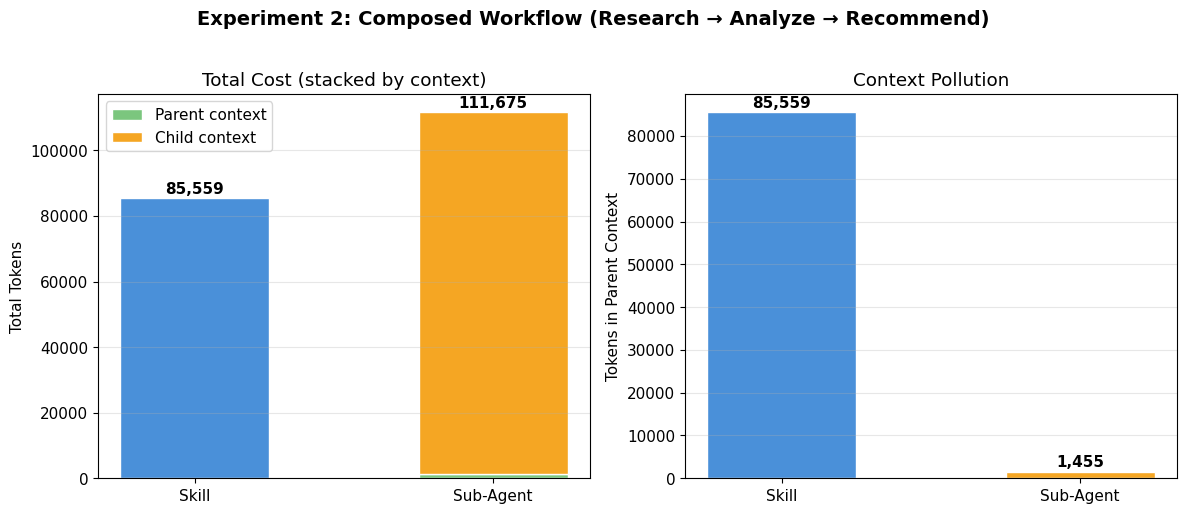


Skill:     85,559 total tokens — ALL in parent context
Sub-Agent: 111,675 total tokens — only 1,455 in parent context

Sub-agent cost 31% more total tokens, but kept parent context 58x cleaner.


In [17]:
# Experiment 2: Side-by-side comparison

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1: Total tokens — stacked for sub-agent
labels = ["Skill", "Sub-Agent"]
skill_total_c = skill_complex["total_tokens"]

ax1.bar(labels[0], skill_total_c, color="#4A90D9", edgecolor="white", width=0.5)
ax1.bar(labels[1], subagent_complex["parent_tokens"], color="#7BC67E", edgecolor="white", width=0.5, label="Parent context")
ax1.bar(labels[1], subagent_complex["child_tokens"], bottom=subagent_complex["parent_tokens"],
        color="#F5A623", edgecolor="white", width=0.5, label="Child context")
ax1.set_ylabel("Total Tokens")
ax1.set_title("Total Cost (stacked by context)")
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

# Labels
ax1.text(0, skill_total_c + 500, f"{skill_total_c:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")
sub_total_c = subagent_complex["total_tokens"]
ax1.text(1, sub_total_c + 500, f"{sub_total_c:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")

# Chart 2: Parent context pollution
skill_parent_c = skill_complex["total_tokens"]
sub_parent_c = subagent_complex["parent_tokens"]

bars2 = ax2.bar(labels, [skill_parent_c, sub_parent_c], color=["#4A90D9", "#F5A623"], edgecolor="white", width=0.5)
ax2.set_ylabel("Tokens in Parent Context")
ax2.set_title("Context Pollution")
for bar, val in zip(bars2, [skill_parent_c, sub_parent_c]):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
             f"{val:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax2.grid(axis="y", alpha=0.3)

plt.suptitle("Experiment 2: Composed Workflow (Research → Analyze → Recommend)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"\nSkill:     {skill_total_c:,} total tokens — ALL in parent context")
print(f"Sub-Agent: {sub_total_c:,} total tokens — only {sub_parent_c:,} in parent context")
delta_pct = (sub_total_c - skill_total_c) / skill_total_c * 100
if delta_pct < 0:
    print(f"\nSub-agent saved {abs(delta_pct):.0f}% on total tokens AND kept parent context {skill_parent_c // sub_parent_c}x cleaner.")
else:
    print(f"\nSub-agent cost {delta_pct:.0f}% more total tokens, but kept parent context {skill_parent_c // max(sub_parent_c, 1)}x cleaner.")

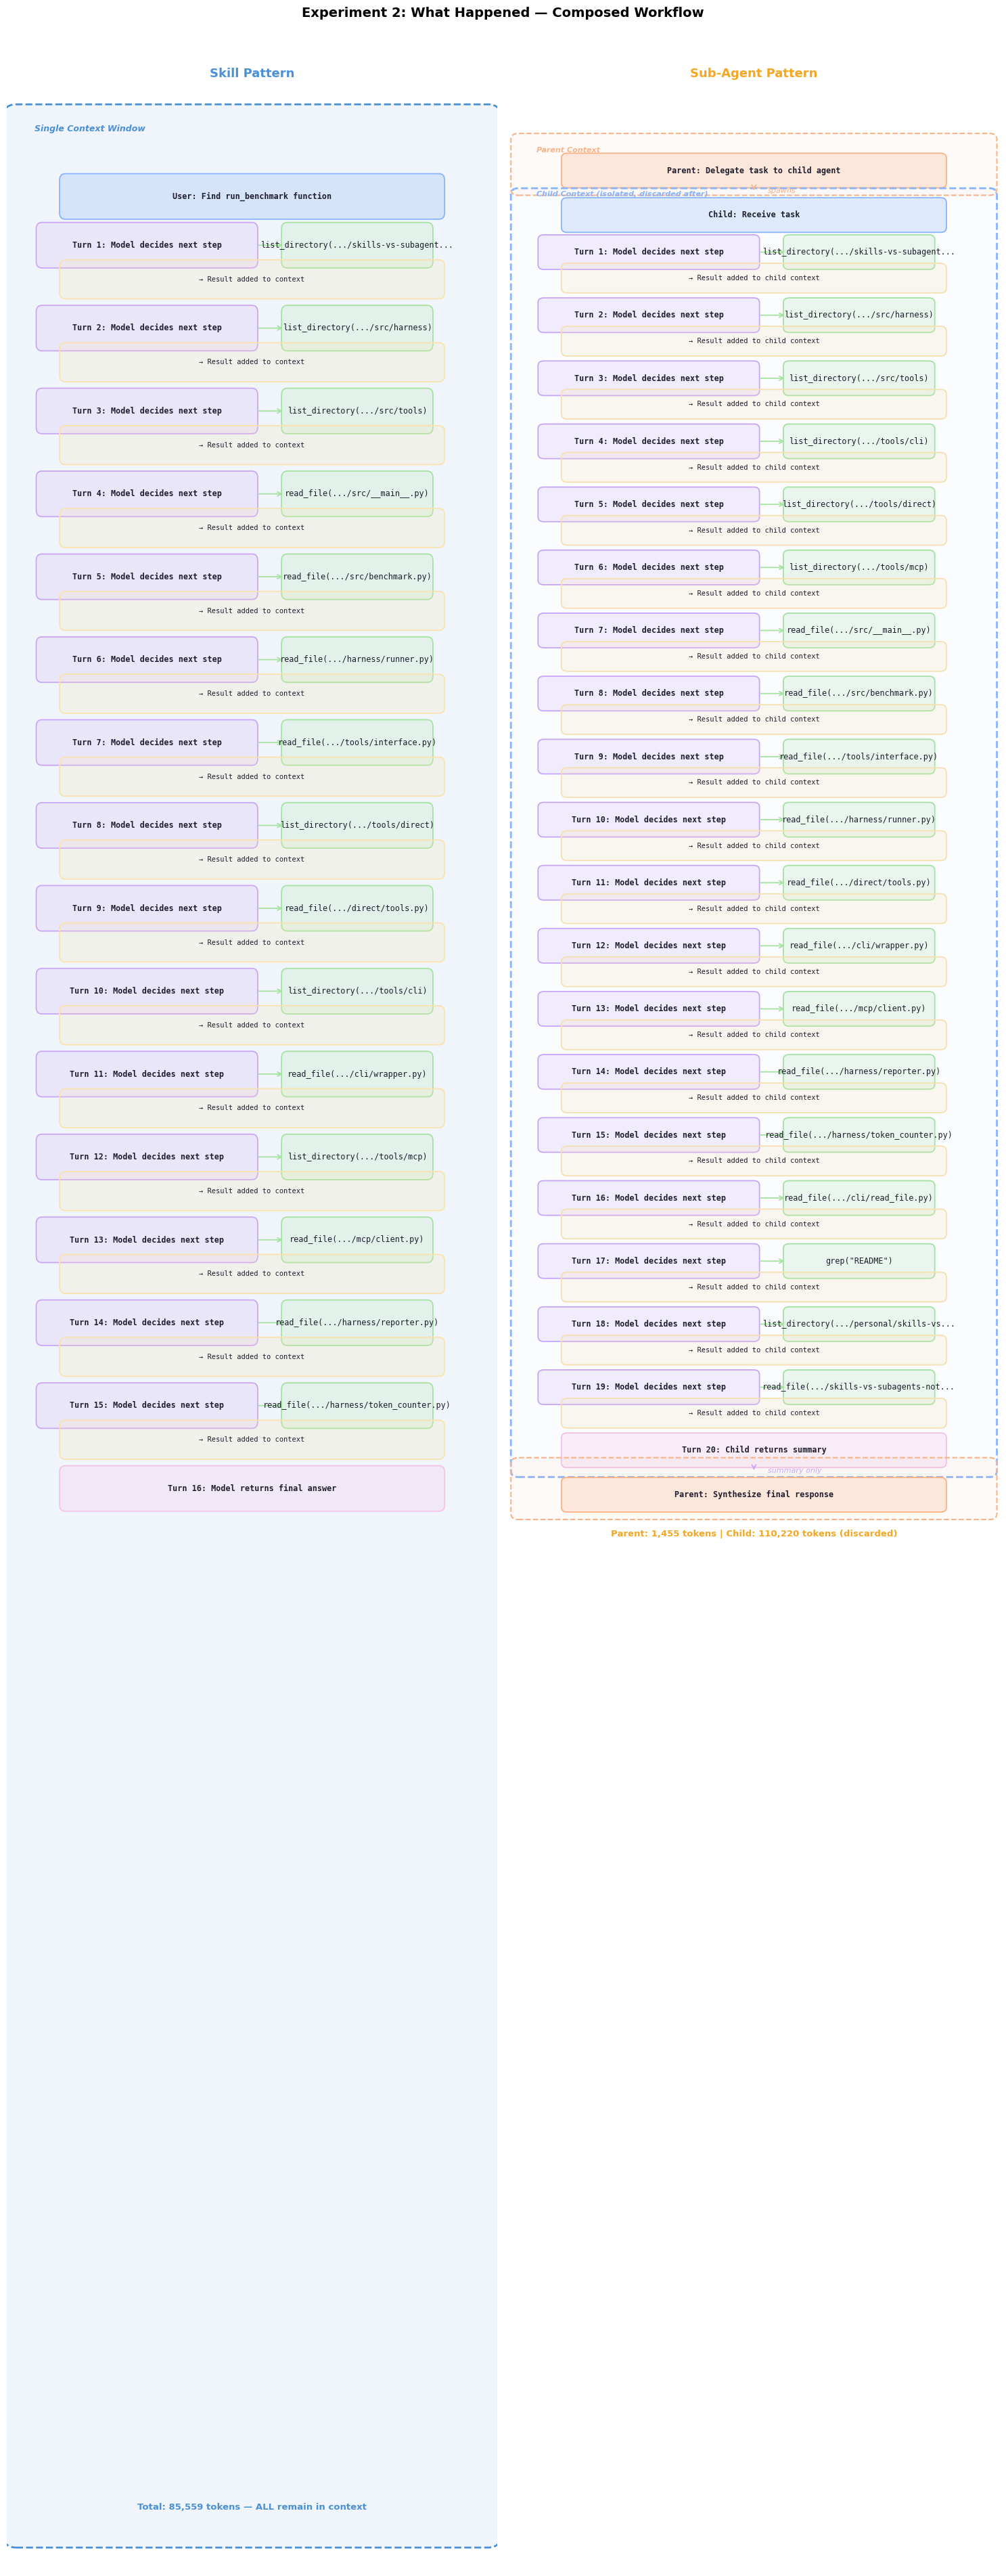

In [18]:
# Experiment 2: Flow Diagrams — What Actually Happened
# Notice how many more tool calls there are — and how ALL of them stay in the skill's context

draw_flow(skill_complex, child_complex, subagent_complex["parent_tokens"],
          title="Experiment 2: What Happened — Composed Workflow")

## Context Accumulation Over Time

The real cost of skills isn't visible in a single task — it's what happens to your conversation context as you keep working.

Imagine you run 3 tasks in sequence. With skills, each task's file contents and tool calls accumulate in the parent context. With sub-agents, the parent only sees summaries.

This is why **context pollution is the dominant concern at scale**, not raw token cost per task.

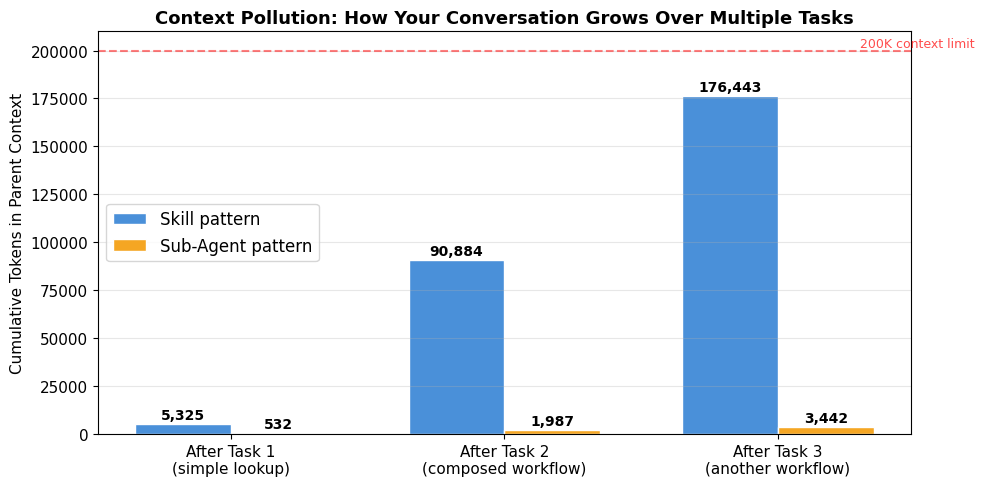


After 3 tasks:
  Skill pattern:     176,443 tokens in parent context
  Sub-Agent pattern: 3,442 tokens in parent context
  That's 51x more context pollution with skills.


In [19]:
# Visualize context accumulation: skills vs sub-agents over multiple tasks

# Simulate running 3 tasks in sequence using our actual measurements
skill_context_after = [
    skill_simple["total_tokens"],
    skill_simple["total_tokens"] + skill_complex["total_tokens"],
    skill_simple["total_tokens"] + skill_complex["total_tokens"] + skill_complex["total_tokens"],  # another complex task
]

subagent_context_after = [
    subagent_simple["parent_tokens"],
    subagent_simple["parent_tokens"] + subagent_complex["parent_tokens"],
    subagent_simple["parent_tokens"] + subagent_complex["parent_tokens"] + subagent_complex["parent_tokens"],
]

fig, ax = plt.subplots(figsize=(10, 5))

tasks = ["After Task 1\n(simple lookup)", "After Task 2\n(composed workflow)", "After Task 3\n(another workflow)"]
x = np.arange(len(tasks))
width = 0.35

bars1 = ax.bar(x - width/2, skill_context_after, width, color="#4A90D9", edgecolor="white", label="Skill pattern")
bars2 = ax.bar(x + width/2, subagent_context_after, width, color="#F5A623", edgecolor="white", label="Sub-Agent pattern")

for bar, val in zip(bars1, skill_context_after):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f"{val:,}", ha="center", va="bottom", fontsize=10, fontweight="bold")
for bar, val in zip(bars2, subagent_context_after):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f"{val:,}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("Cumulative Tokens in Parent Context")
ax.set_title("Context Pollution: How Your Conversation Grows Over Multiple Tasks", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(tasks)
ax.legend(fontsize=12)
ax.grid(axis="y", alpha=0.3)

# Add a "danger zone" line for context window
ax.axhline(y=200_000, color="red", linestyle="--", alpha=0.5, label="200K context limit")
ax.text(2.3, 202_000, "200K context limit", color="red", fontsize=9, alpha=0.7)

plt.tight_layout()
plt.show()

ratio = skill_context_after[-1] / max(subagent_context_after[-1], 1)
print(f"\nAfter 3 tasks:")
print(f"  Skill pattern:     {skill_context_after[-1]:,} tokens in parent context")
print(f"  Sub-Agent pattern: {subagent_context_after[-1]:,} tokens in parent context")
print(f"  That's {ratio:.0f}x more context pollution with skills.")

## Failure Modes

| Skills | Sub-Agents |
|---|---|
| Skill content ignored if context is crowded | Child failures must be caught and handled by orchestrator |
| No isolation — a bad skill can corrupt the whole reasoning trace | Partial failure is recoverable (retry just the failing child) |
| Hard to version/swap at runtime | Each child can run a different model or prompt — composable |
| No parallelism possible | Fan-out enables concurrent execution |

## When to Use Which

**Use a Skill when:**
- The task is single-turn or short-horizon
- You need the model to reason holistically across the domain knowledge and the task at once
- You want low latency and simple orchestration
- The skill is small (< ~1,500 tokens) relative to the full context

**Use a Sub-Agent when:**
- The task is naturally decomposable into independent subtasks
- You need isolation — one subtask's failure shouldn't corrupt others
- You're doing fan-out (e.g., research multiple sources in parallel)
- You want to use different models for different subtasks (e.g., Haiku for classification, Sonnet for synthesis)
- The accumulated context of doing everything in one call would degrade output quality

## The Hybrid Pattern (What Production Systems Often Do)

```
Orchestrator
  ├── loads SKILL.md (orchestration strategy)
  ├── spawns Child A ──► loads domain-specific SKILL.md
  └── spawns Child B ──► loads different SKILL.md
```

The orchestrator uses a skill to know *how to delegate*, while children use skills for domain execution. This keeps each context window focused while still benefiting from structured knowledge injection at every tier.

## The Core Mental Model

> **Skills are about what the model *knows*. Sub-agents are about what the system can *do* in parallel and in isolation.**

Skills extend a model's knowledge *within* a call. Sub-agents extend a model's reach *across* calls. The tradeoff is always **latency + complexity** vs. **context cleanliness + scalability**.